# Model Evaluation

This notebook compares Logistic Regression, Decision Tree, Random Forest, and XGBoost on one stratified 20% holdout. Exact duplicates are removed before splitting. Model selection uses cross-validation on training data only; the holdout is used once for final metrics and visualizations.

## Load, Deduplicate, and Split

Exact duplicate rows are removed before the split to reduce the chance that identical examples land in both train and test. Identifier-like columns are excluded automatically. Missing feature values are imputed inside each model pipeline, fitted only on training folds/data.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split

project_root = next(
    path for path in (Path.cwd(), Path.cwd().parent)
    if (path / "src" / "train_model.py").is_file()
)
sys.path.insert(0, str(project_root))
from src.train_model import RANDOM_STATE, TARGET_COLUMN, build_model_pipelines, load_dataset

sns.set_theme(style="whitegrid")
features, target, data_summary = load_dataset(project_root / "data" / "cm1.csv")
removed_duplicate_count = data_summary["duplicate_rows_removed"]
identifier_columns = data_summary["identifier_columns"]

X_train, X_test, y_train, y_test = train_test_split(
    features,
    target,
    test_size=0.2,
    stratify=target,
    random_state=RANDOM_STATE,
)
print(f"Rows after removing exact duplicates: {len(features):,} (removed {removed_duplicate_count:,})")
print(f"Identifier columns removed: {identifier_columns if identifier_columns else 'none'}")
print(f"Training rows: {len(X_train):,} | Test rows: {len(X_test):,}")
print("Training target counts:")
display(y_train.value_counts().rename_axis(TARGET_COLUMN).to_frame("count"))
print("Test target counts:")
display(y_test.value_counts().rename_axis(TARGET_COLUMN).to_frame("count"))

positive_candidates = [value for value in pd.unique(target) if str(value).strip().lower() in {"true", "1", "yes", "defective"}]
positive_label = positive_candidates[0] if positive_candidates else target.value_counts().idxmin()
print(f"Positive class treated as defective: {positive_label}")

Rows after removing exact duplicates: 442 (removed 56)
Identifier columns removed: none
Training rows: 353 | Test rows: 89
Training target counts:


,count
defects,
False,315
True,38


Test target counts:


,count
defects,
False,79
True,10


Positive class treated as defective: True


## Training-Only Model Selection

Use stratified 5-fold cross-validation on the training split to identify the model with the highest mean F1. The test set does not take part in preprocessing fitting, model selection, or training.

In [2]:
model_pipelines = build_model_pipelines(X_train, y_train)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_results = []

for model_name, pipeline in model_pipelines.items():
    scores = cross_val_score(pipeline, X_train, y_train, scoring="f1", cv=cv, n_jobs=1)
    cv_results.append({"Model": model_name, "Mean CV F1": scores.mean(), "CV F1 Std": scores.std()})

cv_comparison = pd.DataFrame(cv_results).sort_values("Mean CV F1", ascending=False).reset_index(drop=True)
display(cv_comparison)
selected_model_name = cv_comparison.loc[0, "Model"]
print(f"Selected model based only on training CV F1: {selected_model_name}")

,Model,Mean CV F1,CV F1 Std
0,Logistic Regression,0.402569,0.063065
1,XGBoost,0.256702,0.168823
2,Decision Tree,0.178388,0.209220
3,Random Forest,0.000000,0.000000


Selected model based only on training CV F1: Logistic Regression


## Fit and Evaluate on the Holdout

Fit each pipeline on training data only, then calculate accuracy, precision, recall, F1-score, and ROC-AUC on the untouched test data. Recall measures how many defective modules are found; F1 balances recall with precision, which helps limit unnecessary false alarms.

In [3]:
metric_rows = []
fitted_models = {}
test_predictions = {}
test_scores = {}

for model_name, pipeline in model_pipelines.items():
    pipeline.fit(X_train, y_train)
    predictions = pipeline.predict(X_test)
    positive_class_index = list(pipeline.classes_).index(positive_label)
    probabilities = pipeline.predict_proba(X_test)[:, positive_class_index]
    fitted_models[model_name] = pipeline
    test_predictions[model_name] = predictions
    test_scores[model_name] = probabilities
    binary_y_test = (y_test == positive_label).astype(int)
    binary_predictions = (predictions == positive_label).astype(int)
    metric_rows.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(binary_y_test, binary_predictions, zero_division=0),
        "Recall": recall_score(binary_y_test, binary_predictions, zero_division=0),
        "F1-score": f1_score(binary_y_test, binary_predictions, zero_division=0),
        "ROC-AUC": roc_auc_score(binary_y_test, probabilities),
    })

model_comparison = (
    pd.DataFrame(metric_rows)
    .sort_values("F1-score", ascending=False)
    .reset_index(drop=True)
)
display(model_comparison.style.format({
    "Accuracy": "{:.3f}", "Precision": "{:.3f}", "Recall": "{:.3f}",
    "F1-score": "{:.3f}", "ROC-AUC": "{:.3f}",
}))
best_test_f1_model = model_comparison.loc[0, "Model"]
print(f"Highest test F1-score: {best_test_f1_model}")
print(f"Training-CV selected model: {selected_model_name}")
if best_test_f1_model != selected_model_name:
    print("Note: the holdout ranking differs from training-only selection; do not retune against the holdout.")

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
0,Logistic Regression,0.764,0.296,0.800,0.432,0.842
1,Decision Tree,0.831,0.308,0.400,0.348,0.646
2,XGBoost,0.809,0.182,0.200,0.190,0.687
3,Random Forest,0.865,0.000,0.000,0.000,0.711


Highest test F1-score: Logistic Regression
Training-CV selected model: Logistic Regression


## Confusion Matrices

Each matrix shows true versus predicted classes on the holdout. The defective class is labeled explicitly so false negatives (missed defective modules) are easy to identify.

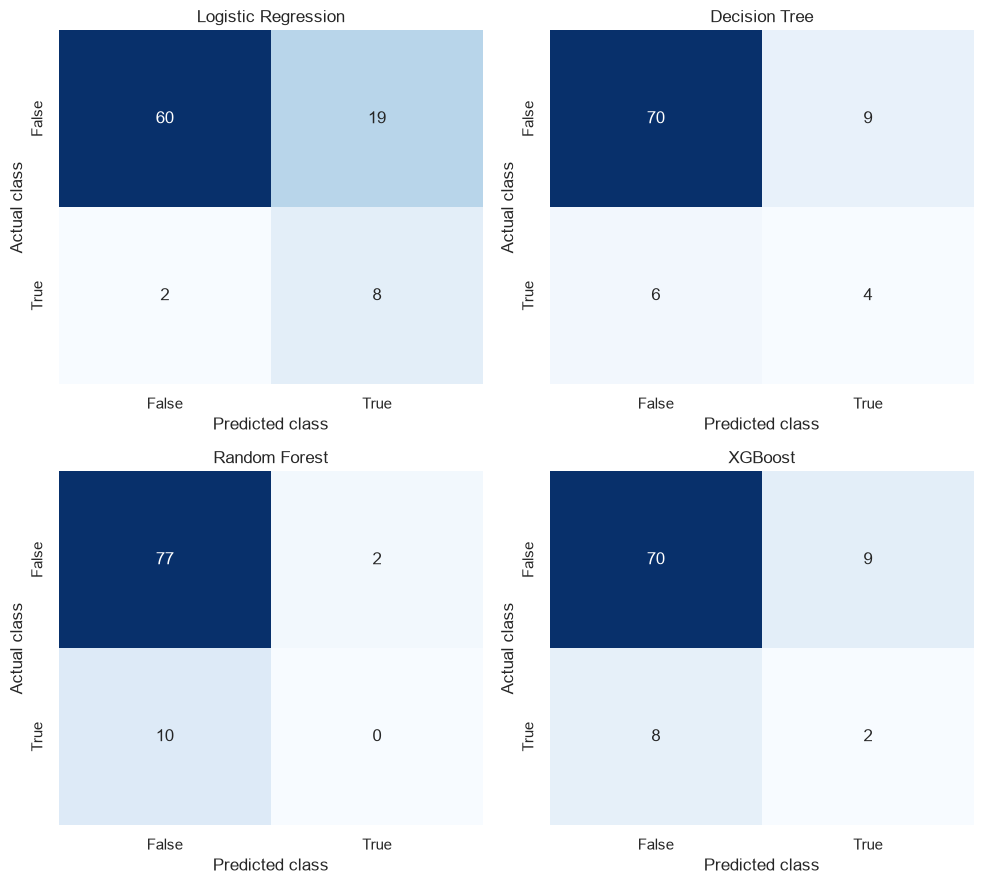

Class labels (False = non-defective, True = defective when Boolean): [np.False_, np.True_]


In [4]:
class_labels = sorted(pd.unique(target), key=lambda value: str(value))
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
for axis, (model_name, predictions) in zip(axes.flat, test_predictions.items()):
    matrix = confusion_matrix(y_test, predictions, labels=class_labels)
    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        xticklabels=class_labels,
        yticklabels=class_labels,
        ax=axis,
    )
    axis.set_title(model_name)
    axis.set_xlabel("Predicted class")
    axis.set_ylabel("Actual class")
plt.tight_layout()
plt.show()
print(f"Class labels (False = non-defective, True = defective when Boolean): {class_labels}")

## ROC Curves

Plot each model's test-set true-positive rate against its false-positive rate across score thresholds. ROC-AUC summarizes ranking performance; the defective class is the positive class.

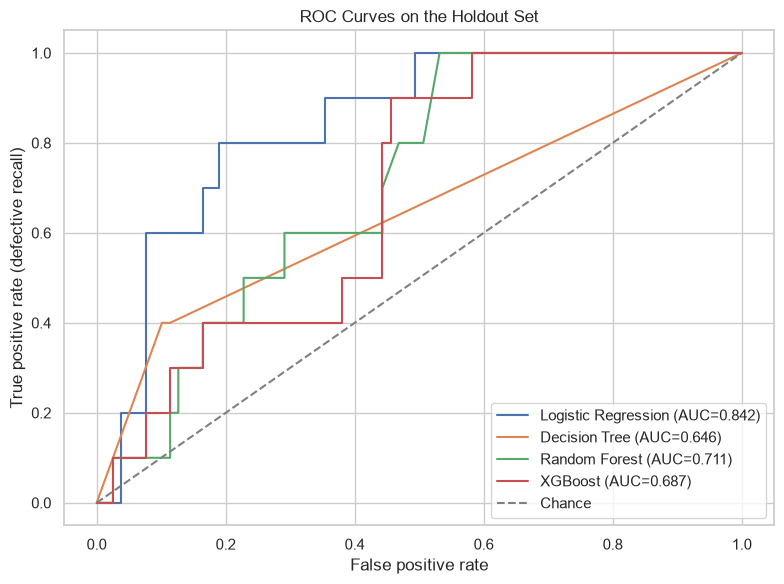

In [5]:
plt.figure(figsize=(8, 6))
for model_name, scores in test_scores.items():
    false_positive_rate, true_positive_rate, _ = roc_curve(y_test, scores, pos_label=positive_label)
    auc_value = roc_auc_score((y_test == positive_label).astype(int), scores)
    plt.plot(false_positive_rate, true_positive_rate, label=f"{model_name} (AUC={auc_value:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate (defective recall)")
plt.title("ROC Curves on the Holdout Set")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## Tree-Based Feature Importance

Show the largest Random Forest and XGBoost feature importances after preprocessing. Encoded categorical features are labeled from the fitted transformer; importance indicates model use, not causal influence.

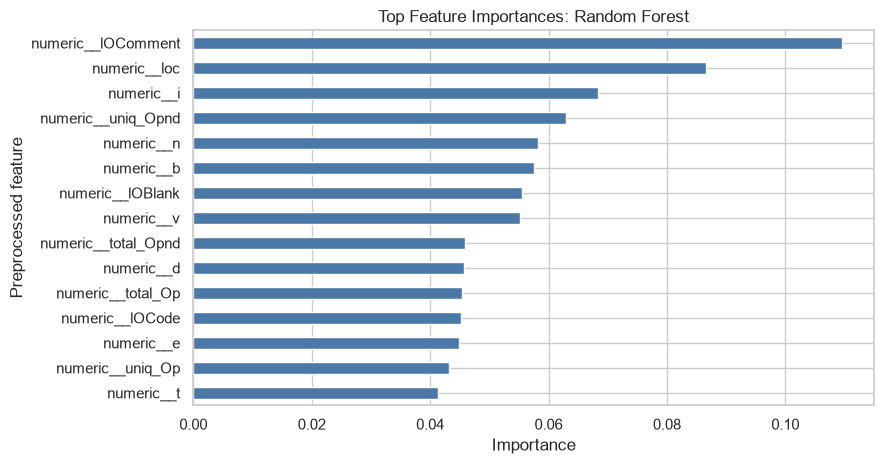

,importance
numeric__lOComment,0.109496
numeric__loc,0.086603
numeric__i,0.068348
numeric__uniq_Opnd,0.062989
numeric__n,0.058226
numeric__b,0.057614
numeric__lOBlank,0.055446
numeric__v,0.055101
numeric__total_Opnd,0.045822
numeric__d,0.045705


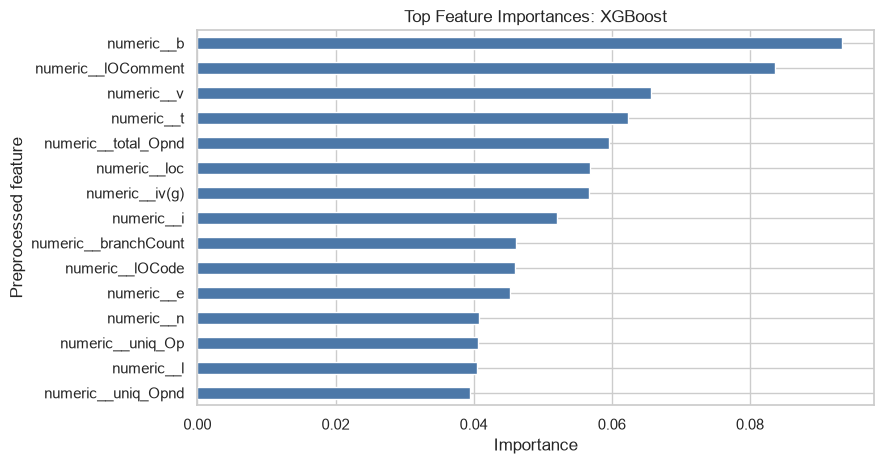

,importance
numeric__b,0.093296
numeric__lOComment,0.083679
numeric__v,0.065746
numeric__t,0.062407
numeric__total_Opnd,0.059554
numeric__loc,0.056819
numeric__iv(g),0.056666
numeric__i,0.052014
numeric__branchCount,0.046072
numeric__lOCode,0.046002


In [6]:
for model_name in ("Random Forest", "XGBoost"):
    fitted_pipeline = fitted_models[model_name]
    estimator = fitted_pipeline.named_steps["model"]
    if not hasattr(estimator, "feature_importances_"):
        print(f"{model_name} does not expose feature_importances_; skipping.")
        continue

    preprocessor = fitted_pipeline.named_steps["preprocessing"]
    transformed_names = preprocessor.get_feature_names_out()
    importance = pd.Series(estimator.feature_importances_, index=transformed_names)
    top_importance = importance.sort_values(ascending=False).head(15).sort_values()

    plt.figure(figsize=(9, max(4, 0.32 * len(top_importance))))
    top_importance.plot(kind="barh", color="#4c78a8")
    plt.title(f"Top Feature Importances: {model_name}")
    plt.xlabel("Importance")
    plt.ylabel("Preprocessed feature")
    plt.tight_layout()
    plt.show()
    display(top_importance.sort_values(ascending=False).rename("importance").to_frame())